In [7]:
import tifffile as tiff
import numpy as np
import glob
import json
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage.morphology import erosion, dilation, disk
from skimage.segmentation import watershed
from scipy import ndimage
from skimage import measure
from scipy import ndimage
from scipy import signal
from scipy.ndimage import median_filter
from skimage.feature import peak_local_max


fileList = glob.glob('/home/thomas/Desktop/strechedC02/*.tif')



In [9]:
import scipy

In [2]:
def downsample(arr):
    n, m = arr.shape
    n3, m3 = n // 3, m // 3
    arr = arr[:n3*3, :m3*3]  # trim extra edges if not divisible by 3

    # Reshape into 3x3 blocks
    arr_blocks = arr.reshape(n3, 3, m3, 3)

    # Compute the median across the 3x3 blocks
    return np.median(arr_blocks, axis=(1, 3))

In [3]:
fileList[5]

'/home/thomas/Desktop/strechedC02/18-49-22_640_667_4239_1_63_6_rl_bl_UltraII_C02_xyz-Table Z0926.ome.tif'

In [4]:
"""
Convert a folder of 2D TIFF slices into a single .raw 8-bit volume
that Unity can load directly into a Texture3D.
"""

import tifffile as tiff
import numpy as np
import json
import os
from tqdm import tqdm

# === CONFIGURATION ===
input_folder = "/home/thomas/Desktop/strechedC02/"      # folder containing slice_0000.tif, slice_0001.tif, ...
output_name  = "/home/thomas/Desktop/c02"    # will produce nerves_volume.raw and nerves_volume.meta
binary_data  = True               # if True, convert all nonzero pixels to 255 for binary mask

# ======================

def load_tiff_stack(folder):
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith(('.tif', '.tiff'))])[10:-10]
    assert files, f"No TIFF files found in {folder}"
    first = tiff.imread(os.path.join(folder, files[0]))
    h, w = first.shape
    d = len(files)
    print(f"Reading stack {w}×{h}×{d}")
    volume = np.zeros((d, 682, 709), dtype=np.uint8)

    for i, fname in enumerate(tqdm(files)):
        img = tiff.imread(os.path.join(folder, fname))
        if binary_data:
            img = (img > 0).astype(np.uint8) * 255
        volume[i] = downsample(img)
    return volume

def save_raw(volume, out_prefix):
    raw_path = out_prefix + ".raw"
    meta_path = out_prefix + ".json"

    volume.tofile(raw_path)
    meta = {"width": volume.shape[2],
            "height": volume.shape[1],
            "depth": volume.shape[0],
            "format": "R8"}
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"Saved RAW data to {raw_path}")
    print(f"Saved metadata to {meta_path}")

'''
if __name__ == "__main__":
    vol = load_tiff_stack(input_folder)
    save_raw(vol, output_name)
'''   


'\nif __name__ == "__main__":\n    vol = load_tiff_stack(input_folder)\n    save_raw(vol, output_name)\n'

In [5]:
volume = load_tiff_stack(input_folder)

Reading stack 2128×2048×2046


100%|██████████| 2046/2046 [00:58<00:00, 35.16it/s]


In [6]:
paded = np.pad(volume, 
                      pad_width=((0, 0), (0, 0), (0, 0)), 
                      mode='constant', 
                      constant_values=0)

In [7]:
paded.shape

(2046, 682, 709)

In [8]:
if __name__ == "__main__":
    save_raw(paded, output_name)

Saved RAW data to /home/thomas/Desktop/c02.raw
Saved metadata to /home/thomas/Desktop/c02.json


In [14]:
# === CONFIGURATION ===
input_folder = "/home/thomas/Desktop/strechedC02/"  # Folder containing slice_0000.tif, slice_0001.tif, ...
output_name  = "/home/thomas/Desktop/c02Test"          # Will produce nerves_volume.raw and nerves_volume.meta
binary_data  = True                                # If True, convert all nonzero pixels to 255 for binary mask

# ======================

def load_tiff_stack(folder):
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith(('.tif', '.tiff'))])[10:-10]
    assert files, f"No TIFF files found in {folder}"
    first = tiff.imread(os.path.join(folder, files[0]))
    h, w = first.shape
    d = len(files)
    print(f"Reading stack {w}×{h}×{d}")
    volume = np.zeros((d, 682, 576), dtype=np.uint8)

    for i, fname in enumerate(tqdm(files)):
        img = tiff.imread(os.path.join(folder, fname))
        if binary_data:
            img = (img > 0).astype(np.uint8) * 255  # Binary mask conversion
        volume[i] = downsample(img)  # Assuming downsample function is defined
    return volume

def save_raw(volume, out_prefix):
    raw_path = out_prefix + ".raw"
    meta_path = out_prefix + ".json"
    volume.tofile(raw_path)
    meta = {"width": volume.shape[2],
            "height": volume.shape[1],
            "depth": volume.shape[0],
            "format": "R8"}
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)
    print(f"Saved RAW data to {raw_path}")
    print(f"Saved metadata to {meta_path}")

'''def apply_morphological_operations(volume, dilate_iterations=2, strength=2):
    print("Applying dilation before erosion...")
    # Dilation first: Expands regions and connects nearby structures
    for j in range(dilate_iterations):
        for i in range(volume.shape[0]):
            for _ in range(strength):
                volume[i] = dilation(volume[i], disk(1))  # Disk-shaped structuring element, adjust size if needed
        
        # Erosion second: Shrinks regions and removes small noise
        for i in range(volume.shape[0]):
            for _ in range(strength):
                volume[i] = erosion(volume[i], disk(1))  # Adjust size of structuring element if needed


    return nerves_volume

def apply_morphological_operations(volume,iterations=1):
    # Ensure the volume is binary (0 and 1 values)
    volume = volume.astype(bool)
    
    # 3D structuring element
    struct = ndimage.generate_binary_structure(3, 1)  # 3D structure
    # Apply erosion and dilation in 3D
    volume = ndimage.binary_dilation(volume, structure=struct, iterations=2)
    volume = ndimage.binary_erosion(volume, structure=struct, iterations=2)
    for i in range(10):
        volume = ndimage.binary_erosion(volume, structure=struct, iterations=2)
        volume = ndimage.binary_dilation(volume, structure=struct, iterations=2)
    return volume
    '''

def apply_morphological_operations(volume, iterations=4):
    # Ensure the volume is binary (0 and 1 values)
    volume = volume.astype(bool)
    
    # Define a custom structuring element: preferential expansion along the z-axis
    struct = np.zeros((5, 5, 5), dtype=bool)  # A 3x3x3 structuring element
    struct[2:4, 2:4, :] = 1  # Fill the z-axis (top and bottom of the z dimension)
    #struct[3, 2:4, 3] = 1  # Fill the xy radial direction (excluding corners)
    #struct[2:4,3,3] = 1
    # Apply dilation and erosion in 3D with the custom structuring element
    for _ in range(iterations):
        volume = ndimage.binary_dilation(volume, structure=struct, iterations=1)
        volume = ndimage.binary_erosion(volume, structure=struct, iterations=1)

    return volume



# Apply watershed segmentation
def apply_watershed(volume):
    print("Applying watershed segmentation...")
    # We assume volume is a binary mask. We can use distance transform followed by watershed.
    labels = np.zeros_like(volume)
    for i in range(volume.shape[0]):
        # Compute the distance transform of the binary image
        distance = ndimage.distance_transform_edt(volume[i] > 0)
        # Find local maxima
        local_max = peak_local_max(footprint=np.ones((3, 3)), labels=volume[i] > 0)
        # Watershed: labels the different regions
        labels[i] = watershed(-distance, markers=local_max, mask=volume[i] > 0)
    return labels



def z_wise_median_filter(volume, size=3):
    # Ensure the volume is a 3D numpy array
    volume = volume.astype(np.bool)

    # Apply median filter along the z-axis (axis=0)
    filtered_volume = median_filter(volume, size=(size, 1, 1), mode='nearest')

    return filtered_volume


def process_volume(volume, operation='watershed'):
    if operation == 'morphological':
        # Apply erosion and dilation
        volume = apply_morphological_operations(volume)
    elif operation == 'watershed':
        # Apply watershed segmentation
        volume = apply_watershed(volume)
    else:
        print(f"Unknown operation {operation}")
    #return z_wise_median_filter(volume)
    return volume

# Main function
if __name__ == "__main__":
    #vol = load_tiff_stack(input_folder)
    
    # Choose operation: 'morphological' or 'watershed'
    operation = 'morphological'  # Change to 'watershed' if you want to apply watershed instead
    vol1 = np.array(scipy.signal.medfilt(np.array(process_volume(vol, operation),dtype=np.uint8),kernel_size=(5,1,1)),dtype=np.bool)

    
    # Save processed volume
    save_raw(vol1, output_name)


Saved RAW data to /home/thomas/Desktop/c02Test.raw
Saved metadata to /home/thomas/Desktop/c02Test.json


In [8]:
vol.shape

(2046, 682, 576)

In [ ]:
scipy.signal.medfilt()

In [ ]:
save_raw(vol, output_name)

Saved RAW data to /home/thomas/Desktop/c02Test.raw
Saved metadata to /home/thomas/Desktop/c02Test.json


In [ ]:
struct = ndimage.generate_binary_structure(1, 1)
# Scipy erosion
erodedMask1 = ndimage.binary_erosion(vol.astype(uint), structure=struct, iterations=1)

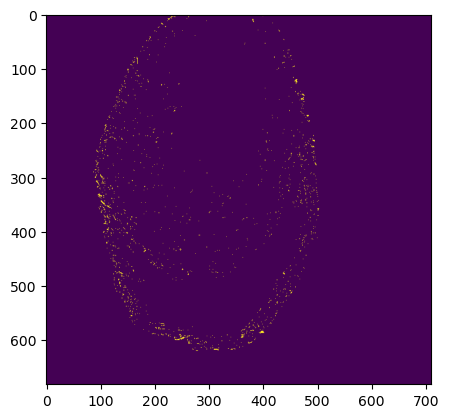

In [ ]:
plt.imshow(vol[600])

In [ ]:
vol = process_volume(vol, operation)

Applying watershed segmentation...


TypeError: peak_local_max() got an unexpected keyword argument 'indices'